# Project 3

group:
- Ole Lie-Bjelland
- Anniken Marie Lingstad
- Emil Ingar Hals

We did NOT use any AI for this project.

## Topic 1

### Task 0

Our coordnate box will use angstrom units. To ensure that all the points in the dna molecule fit in the box we found the lowest and highest of each x,y,z value in the dna_coords.txt file. The box is then expanded by 5 angstrom in every direction to ensure that the atomic radius of each point remains inside the simulation box

In [12]:
from main import gen_simulation_box

simulation_box = gen_simulation_box(10, 10, 10)
simulation_box_volume = simulation_box.volume()

print(f"Simulation box: {simulation_box}")
print(f"Simulation box volume: {simulation_box_volume}")

Simulation box: 
min x: 0
max x: 10
min y: 0
max y: 10
min z: 0
max z: 10

Simulation box volume: 1000


### Task 1

In [13]:
from main import gen_random_points

point_count = 3
points = gen_random_points(simulation_box, point_count)
print(f"Generated {len(points)} random points:")
for p in points:
    print(p)

Generated 3 random points:
x: 8.214122708429652
y: 8.936108126933997
z: 6.977493677189007

x: 7.266967450259509
y: 7.0998827043325194
z: 4.035497256672769

x: 9.83691334345588
y: 9.092192620633945
z: 5.5963073374692325



### Task 2

In [14]:
from main import gen_spheres

spheres = gen_spheres(simulation_box, 1)
for s in spheres:
    print(s)

Sphere radius: 1.1270678720703868
Sphere location:
x: 5.223163480986207
y: 3.451039296192993
z: 2.47158731623629



### Task 3

In [15]:
from main import point_in_spheres

rand_point = gen_random_points(simulation_box, 1)[0]
print(f"Point: \n{rand_point}")

assert point_in_spheres(spheres, spheres[0].point), "point_in_spheres function not working"   # This should always be true

if point_in_spheres(spheres, rand_point):
    print("The point is in the sphere")
else:
    print("The point is not in the sphere")


Point: 
x: 6.226532109558869
y: 6.615899306683622
z: 5.251552083157225

The point is not in the sphere


### Task 4

We can check the montecarlo simulation result by comparing it to the volume of a sphere given by the formula: $V = \frac{4}{3} \pi r^3$


sphere radius is: 1.561925765263183
The fraction of points in the sphere is 0.01616333333333333
The volume of the simulation box is: 1000
Estimated volume of sphere: 16.16333333333333
Analytical volume of sphere: 15.9613557131404


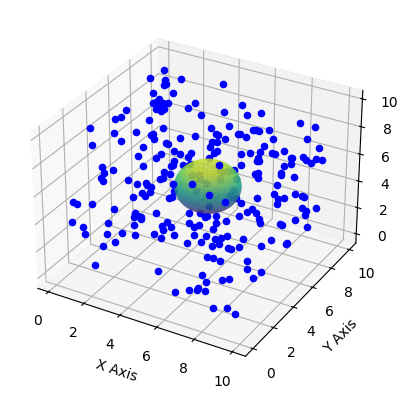

In [16]:
num_of_points = 300000
sphere = gen_spheres(simulation_box, 1)
random_points = gen_random_points(simulation_box, num_of_points)

print(f"sphere radius is: {sphere[0].rad}")

points_in_sphere = 0
for point in random_points:
    if point_in_spheres(sphere, point):
        points_in_sphere += 1

estimated_volume = simulation_box.volume() * (points_in_sphere/num_of_points)

print(f"The fraction of points in the sphere is {points_in_sphere/num_of_points}")
print(f"The volume of the simulation box is: {simulation_box.volume()}")
print(f"Estimated volume of sphere: {estimated_volume}")
print(f"Analytical volume of sphere: {sphere[0].volume()}")

# Plotting
from main import plot_points_and_spheres
plot_points_and_spheres(sphere, random_points[:250])   # Only plotting 250 points because plotting all of them is very slow


### Task 5

$$
V = \frac{4}{3} \pi r^3 \to \pi = \frac{3V}{4 \cdot r^3}
$$

In [17]:
estimated_pi = (estimated_volume*3)/(4*sphere[0].rad**3)
print(f"Estimated pi: {estimated_pi}")

Estimated pi: 3.181346883693523


### Task 6

In [18]:
spheres = gen_spheres(simulation_box, 10)

# Show the first 3 of the 10 new spheres
for s in spheres[:3]:
    print(s)

Sphere radius: 1.3760624589885015
Sphere location:
x: 8.465260795540107
y: 5.276589822723054
z: 1.9693359340970527

Sphere radius: 1.1117099569282467
Sphere location:
x: 7.767385957167329
y: 4.1638032437276635
z: 2.669856289480378

Sphere radius: 1.8593667923652215
Sphere location:
x: 4.428873322667713
y: 7.959282594443318
z: 5.957350824854741



### Task 7

We can verify the results of the simulation in the same way as in task 4. As we know the radius of all the spheres we can calculate their total volume analytically.

Total volume of simulation box: 1000
The fraction of points in the sphere is 0.18385
The total volume of the generated spheres is: 183.71
The estimated volume is 183.85000000000002


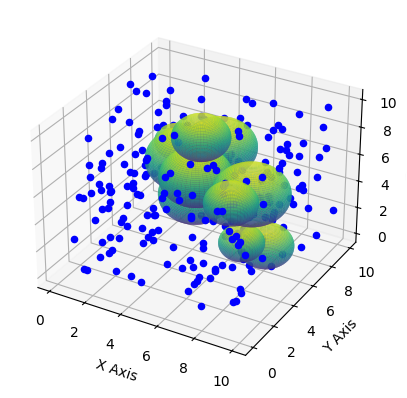

In [19]:
num_of_points = 300000
random_points = gen_random_points(simulation_box, num_of_points)

# Calculate the analytical volume
total_volume = 0
for s in spheres:
    total_volume += s.volume()

points_in_spheres = 0
for point in random_points:
    points_in_spheres += point_in_spheres(spheres, point)

fraction = points_in_spheres/num_of_points
estimated_volume = simulation_box.volume() * fraction
print(f"Total volume of simulation box: {simulation_box.volume()}")
print(f"The fraction of points in the sphere is {fraction}")
print(f"The total volume of the generated spheres is: {round(total_volume, 2)}")
print(f"The estimated volume is {estimated_volume}")

# Plotting
plot_points_and_spheres(spheres, random_points[:250])

### Task 8

In [20]:
from main import get_atoms
atoms = get_atoms()
for a in atoms[:3]:
    print(a)


Atomic symbol: H
Atomic radius: 1.2 angstrom
Position: 
x: -48.18074
y: 1.74518
z: -1.22092



Atomic symbol: O
Atomic radius: 1.52 angstrom
Position: 
x: -48.07374
y: 1.26418
z: -0.40592



Atomic symbol: P
Atomic radius: 1.8 angstrom
Position: 
x: -46.63374
y: 1.27818
z: -0.00492




### Task 9

In [21]:
from main import get_dna_box
dna_box = get_dna_box(atoms)
print("Simulation box for DNA:")
print(dna_box)
print(f"Volume of DNA box: {dna_box.volume()}")

Simulation box for DNA:

min x: -54
max x: -25
min y: -23
max y: 8
min z: -15
max z: 15

Volume of DNA box: 26970


### Task 10

In order to find the analytical volume of the DNA we can use the normal formula for the volume of a sphere as we already know the atomic radius of each atom.

In [22]:
random_point_count = 100000
random_points = gen_random_points(dna_box, random_point_count)

# Check how many of the random points are in the dna
points_in_dna = 0
for p in random_points:
    points_in_dna += point_in_spheres(atoms, p)

fraction = points_in_dna/random_point_count
estimated_dna_volume = dna_box.volume()*fraction

print(f"Volume of simulation box: {dna_box.volume()}")
print(f"Fraction of points in dna: {fraction}")
print(f"Estimated dna volume: {estimated_dna_volume} angstrom^3")


# Analytical approach
import math
analytical_dna_volume = 0
for atom in atoms:
    analytical_dna_volume += math.pi * (4/3) * atom.rad**3

print(f"analytical dna volume: {analytical_dna_volume} angstrom^3")


Volume of simulation box: 26970
Fraction of points in dna: 0.13476
Estimated dna volume: 3634.4772 angstrom^3
analytical dna volume: 3672.2768725392457 angstrom^3


## Topic 2

### Task 1

A simple random walk function without numpy to generate a set of walkers in 3d, starting from different random points. Imported from random_walk.py

Walker 1 start: 24.402709037868746, 19.122681726427544, 68.41963521936373
Walker 2 start: 74.06330791766513, 59.63740192905962, 6.138009196812604
Walker 3 start: -78.21620617416477, 34.476363379272016, 70.7828426903751
Walker 4 start: 33.950697865930806, 28.174094722431903, 25.092614188241896
Walker 5 start: 27.523566891120723, -38.23848672134895, -65.54372880110652


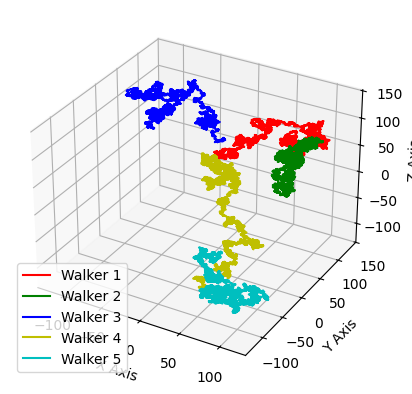

In [33]:
from random_walk import gen_walkers
import matplotlib.pyplot as plt

ITERATIONS = 10000
WALKER_COUNT = 5

walkers = gen_walkers(ITERATIONS, WALKER_COUNT)

# Plotting the random walk
# Source for plot code:
# https://stackoverflow.com/questions/11541123/how-can-i-make-a-3d-line-plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'y', 'c', 'm']

for i, w in enumerate(walkers):
    x_vals = [p[0] for p in w.past_positions]
    y_vals = [p[1] for p in w.past_positions]
    z_vals = [p[2] for p in w.past_positions]

    ax.plot(x_vals, y_vals, z_vals, color=colors[i % len(colors)], label=f'Walker {i+1}')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.legend()
plt.show()

### Task 3

A strategy for calculating accesible volume of the DNA is to place the walkers in the box, and let them walk until they hit a DNA point. This leaves a trail we can track and a minimum of the volume the atoms can travel within the space. The more walkers we have the more accurate the results, since more space will be covered.

### Task 4

A test to verify our strategy would be to place an object of known volume, for example a sphere, in a box with known total volume, then see how accurate the walkers are to estimate the space around the sphere. Since we don't know how many walkers are necessary, it would be a good idea to test with different amounts.